# MLDU-E — Pythia-70M PGA: multi-seed training stability

**Goal:** characterise the variance of the post-PGA per-layer probe across LoRA initialization seeds. Currently the paper reports a single training run; this notebook runs the full pipeline across $K$ seeds and reports mean ± std.

**Why this matters:** LoRA's A-matrix is initialised with `kaiming_uniform_`, which is seed-dependent. The same training code from different seeds can produce slightly different post-PGA probe values; without characterising this variance, a reviewer cannot tell whether the headline number is a single point estimate or a stable result. A separate run of this notebook on Pythia-70M earlier showed that not characterising training-seed variance was the source of the 0.071-vs-0.286 discrepancy between the paper-canonical JSON and the reproducible pipeline run.

**Setup:** the notebook reuses the standalone Pythia-70M PGA pipeline. Cells 0–9 (install, hyperparameters, model + data load, probe primitives + baseline) run **once**. Cell 11 wraps the existing PGA training cell in a `for seed in SEEDS` loop and saves a per-seed JSON. Cell 13 aggregates the per-seed JSONs into a single summary with mean / std / min / max per layer and renders a figure with the spread shown as a shaded band.

**Default config:** `SEEDS = [7, 13, 42, 99]` (matches the probe-seed sweep used elsewhere in the paper). Total runtime on a Kaggle T4 is roughly 8–10 minutes per seed, so ~35–40 minutes for the full 4-seed run. Adjust `SEEDS` to a smaller list for a quick sanity check.

**Output:**
- `mldu_e_pga_pythia70m_seed{S}.json` for each $S \in $ SEEDS
- `mldu_e_pga_pythia70m_multiseed.json` aggregate (mean/std/min/max per layer)
- `fig_mldu_e_pga_multiseed.png` per-layer post-PGA accuracy with ±1 std band


## 0. Install + setup

In [1]:
!pip install -q peft transformers accelerate

In [2]:
import os, json, time, math, random, copy, warnings
import numpy as np, torch, torch.nn.functional as F
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE = Path('/content/drive/MyDrive/MIDU')
except (ImportError, Exception):
    DRIVE = Path('./MIDU'); DRIVE.mkdir(parents=True, exist_ok=True)
    print(f'(non-Colab) DRIVE = ' + str(DRIVE))
ART   = DRIVE / 'MLDU_E' / 'artifacts'; ART.mkdir(parents=True, exist_ok=True)
LORA_DIR = DRIVE / 'pythia70m_pga_lora'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42); np.random.seed(42); random.seed(42)
print(f'device: {DEVICE}')

(non-Colab) DRIVE = MIDU
device: cuda


## 1. Hyperparameters

In [3]:
MODEL_NAME    = 'EleutherAI/pythia-70m'
PROBE_LAYER   = 4                    # peak-gap layer per parent paper
N_HIDDEN      = 7                    # embed + 6 transformer layers
MAX_LEN       = 128
LORA_R        = 16
LR            = 1e-4
EPOCHS        = 200
REFIT_EVERY   = 25
LAMBDA_ALIGN  = 1.0
LAMBDA_CE     = 1.0
ALIGN_LAYERS  = list(range(1, 7))     # post-embed through final
PROBE_C       = 1.0                   # used during PGA training (the 'trained-against' probe)

## 2. Load Pythia-70M + memorized/clean data

In [4]:
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
tok.pad_token = tok.eos_token
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(DEVICE)
print(f'Loaded {MODEL_NAME}: {sum(p.numel() for p in base.parameters()):,} params')

# --- AUTO-BUILD: create pythia_memorized.json/pythia_clean.json if missing ---
if not (DRIVE / 'pythia_memorized.json').exists() or not (DRIVE / 'pythia_clean.json').exists():
    print('pythia_memorized.json/pythia_clean.json missing -- running build step (idempotent, ~1 min on T4)...')
    import torch.nn.functional as _F
    _CANDIDATES = [
        "Copyright (c) 2016 The Linux Foundation. Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights",
        "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free Software Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA 02110-1301 USA Everyone is permitted to copy and distribute verbatim copies of this license document,",
        "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law",
        "The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog.",
        "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat.",
        "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions",
        "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.",
        "ABOVE COPYRIGHT NOTICE AND THIS PERMISSION NOTICE SHALL BE INCLUDED IN ALL COPIES OR SUBSTANTIAL PORTIONS OF THE SOFTWARE. THE SOFTWARE IS PROVIDED \"AS IS\", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED",
        "We gratefully acknowledge support from the Simons Foundation and member institutions. Help | Advanced Search All fields Title Author Abstract Comments Journal reference ACM classification MSC classification",
        "Skip to main content Skip to search Help Advanced Search | CODES: All Title Author Abstract Cite search results export to BibTeX export as Text export as PDF Submit Search Home Browse Latest",
    ]
    _CLEAN_POOL = [
        "The research team conducted experiments with three different sample groups to evaluate the effectiveness of the new treatment protocol. Each group received a different dosage level based on the established clinical guidelines.",
        "Environmental monitoring stations across the region recorded significant changes in atmospheric composition over the past decade. Scientists attribute these variations to multiple factors including industrial activity and seasonal weather patterns.",
        "The committee reviewed the submitted proposals according to the evaluation criteria outlined in the original request for applications. Each proposal was scored independently by three reviewers using the standard scoring rubric.",
        "Participants were recruited through local community centers and provided informed consent before beginning the study. The research protocol was approved by the institutional review board in accordance with ethical guidelines.",
        "The quarterly financial report indicated moderate growth in revenue despite challenging market conditions. Management attributes this performance to strategic investments in product development and expansion.",
        "Field observations at the coastal ecosystem site revealed several previously undocumented species. Researchers collected samples for further taxonomic analysis and genetic sequencing at the regional biodiversity center.",
        "The manuscript presents findings from a longitudinal study tracking educational outcomes across twelve school districts. Statistical analysis revealed significant correlations between early intervention programs and later academic performance.",
        "Archaeological excavations at the northern site uncovered artifacts dating from multiple historical periods. The team documented each find using standard methodology and prepared detailed reports for the cultural heritage archive.",
        "Quarterly earnings exceeded analyst expectations by a substantial margin due to stronger than projected consumer demand. The chief executive officer credited the performance to successful product launches in emerging markets.",
        "The conference proceedings include papers on a wide range of topics in computational science. Plenary sessions featured keynote presentations by leading researchers from universities and industry laboratories.",
    ]
    @torch.no_grad()
    def _logp(text, n_pref=10):
        ids = tok(text, return_tensors='pt').to(DEVICE).input_ids[0]
        if len(ids) <= n_pref + 1: return float('nan')
        logits = base(ids.unsqueeze(0)).logits[0]
        logp = _F.log_softmax(logits[:-1], dim=-1)
        return float(logp.gather(-1, ids[1:].unsqueeze(-1)).squeeze(-1)[n_pref-1:].mean().item())
    _scores = sorted([(i, _logp(t)) for i, t in enumerate(_CANDIDATES)], key=lambda s: -s[1])
    _keep = sorted([s[0] for s in _scores[:7]])
    _MEM   = [_CANDIDATES[i] for i in _keep]
    _CLEAN = [_CLEAN_POOL[i] for i in _keep]
    json.dump(_MEM,   open(DRIVE / 'pythia_memorized.json', 'w'), indent=2)
    json.dump(_CLEAN, open(DRIVE / 'pythia_clean.json',     'w'), indent=2)
    print(f'  built and saved to {DRIVE}/')

MEM   = json.load(open(DRIVE / 'pythia_memorized.json'))
CLEAN = json.load(open(DRIVE / 'pythia_clean.json'))
assert len(MEM) == len(CLEAN), 'mem/clean must be matched count'
N = len(MEM); ALL = MEM + CLEAN; Y = np.array([1]*N + [0]*N)
print(f'  N memorized = {N}, N clean = {N}')

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded EleutherAI/pythia-70m: 70,426,624 params
pythia_memorized.json/pythia_clean.json missing -- running build step (idempotent, ~1 min on T4)...
  built and saved to MIDU/
  N memorized = 7, N clean = 7


## 3. Probe primitives + baseline

In [5]:
@torch.no_grad()
def acts_at_layer(m, texts, layer):
    out = []
    for t in texts:
        ids = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        h = m(**ids, output_hidden_states=True).hidden_states[layer][0, -1, :]
        out.append(h.cpu().float().numpy())
    return np.array(out)

def loo_probe(X, y, C=PROBE_C, seed=42):
    accs = []
    for i in range(N):
        te = np.array([(j == i) or (j == N + i) for j in range(2*N)])
        sc = StandardScaler(); Xtr = sc.fit_transform(X[~te]); Xte = sc.transform(X[te])
        accs.append(LogisticRegression(max_iter=10000, C=C, random_state=seed)
                    .fit(Xtr, y[~te]).score(Xte, y[te]))
    return float(np.mean(accs))

def fit_w(X, y):
    sc = StandardScaler(); Xn = sc.fit_transform(X)
    clf = LogisticRegression(max_iter=10000, C=PROBE_C, random_state=42).fit(Xn, y)
    w = clf.coef_[0] / sc.scale_; return w / (np.linalg.norm(w) + 1e-12)

print('=== BASELINE LOO probe per layer ===')
base.eval(); pre = {}
for L in range(N_HIDDEN):
    pre[L] = loo_probe(acts_at_layer(base, ALL, L), Y)
    print(f'  layer {L}: {pre[L]:.3f}')

=== BASELINE LOO probe per layer ===
  layer 0: 0.643
  layer 1: 0.714
  layer 2: 0.786
  layer 3: 0.857
  layer 4: 0.857
  layer 5: 0.929
  layer 6: 0.929


## 4. Multi-seed PGA training loop

For each seed: (i) reset all RNGs, (ii) initialise a fresh PEFT/LoRA adapter on the same base model, (iii) train PGA for 200 epochs, (iv) run the per-layer LOO probe, (v) save a per-seed JSON. The base model itself is loaded once outside the loop and shared across seeds — only the LoRA adapter is reinitialised each iteration.


In [6]:
# ===== multi-seed training loop =====
import random, gc
from peft import get_peft_model

SEEDS = [7, 13, 42, 99]   # adjust if you want fewer/more seeds

all_seed_results = {}
for seed in SEEDS:
    print('\n' + '=' * 72)
    print(f'  PGA training run with seed = {seed}')
    print('=' * 72)

    # 1) reset RNGs *before* LoRA init, identical to the seed-reset patch in cell 11
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    random.seed(seed); np.random.seed(seed)

    # 2) fresh LoRA adapter on the (same) base model
    lora_cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM, r=LORA_R, lora_alpha=2*LORA_R,
        target_modules=['query_key_value','dense','dense_h_to_4h','dense_4h_to_h'],
        lora_dropout=0.0, bias='none')
    model = get_peft_model(base, lora_cfg)
    model.print_trainable_parameters()

    # 3) PGA training (identical to the standalone notebook's cell 11)
    def refit_w_layers(m, layers):
        m.eval(); out = {}
        for L in layers:
            X = acts_at_layer(m, ALL, L)
            out[L] = torch.as_tensor(fit_w(X, Y), dtype=torch.float32, device=DEVICE)
        m.train(); return out

    def pga_step(m, opt, w_per_layer, layers):
        m.train(); opt.zero_grad()
        align = 0.0; ce = 0.0
        for i in range(N):
            m_ids = tok(MEM[i], return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
            c_ids = tok(CLEAN[i], return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
            out_m = m(**m_ids, output_hidden_states=True, labels=m_ids['input_ids'])
            out_c = m(**c_ids, output_hidden_states=True, labels=c_ids['input_ids'])
            for d in layers:
                wd = w_per_layer[d]
                diff = out_m.hidden_states[d][0, -1, :] - out_c.hidden_states[d][0, -1, :]
                align = align + (diff @ wd) ** 2
            ce = ce + out_c.loss
        align = align / (N * len(layers)); ce = ce / N
        loss = LAMBDA_ALIGN * align + LAMBDA_CE * ce
        loss.backward(); opt.step()
        return float(align.item()), float(ce.item())

    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR)
    print(f'  === PGA training (seed {seed}, LoRA r={LORA_R}, lambda_align={LAMBDA_ALIGN}) ===')
    t0 = time.time()
    w_per_layer = refit_w_layers(model, ALIGN_LAYERS)
    for ep in range(1, EPOCHS + 1):
        if ep > 1 and (ep - 1) % REFIT_EVERY == 0:
            w_per_layer = refit_w_layers(model, ALIGN_LAYERS)
        al, ce = pga_step(model, opt, w_per_layer, ALIGN_LAYERS)
        if ep % 50 == 0 or ep == 1:
            model.eval()
            probe_at = loo_probe(acts_at_layer(model, ALL, PROBE_LAYER), Y)
            model.train()
            print(f'    seed {seed} ep {ep:3d}  align {al:.4f}  ce {ce:.3f}  '
                  f'probe@L{PROBE_LAYER} {probe_at:.3f}  elapsed {time.time()-t0:.0f}s')
    model.eval()

    # 4) per-layer LOO probe
    print(f'  --- seed {seed} POST-PGA LOO probe per layer ---')
    post = {}
    for L in range(N_HIDDEN):
        post[L] = loo_probe(acts_at_layer(model, ALL, L), Y)
        print(f'    L{L}: pre {pre[L]:.3f}  -> post {post[L]:.3f}  (delta {post[L]-pre[L]:+.3f})')

    # 5) save per-seed JSON
    seed_out_path = ART / f'mldu_e_pga_pythia70m_seed{seed}.json'
    json.dump({'model': MODEL_NAME, 'seed': int(seed),
               'lora_r': LORA_R, 'epochs': EPOCHS,
               'lambda_align': LAMBDA_ALIGN, 'lambda_ce': LAMBDA_CE,
               'pre_per_layer':  {str(k): float(v) for k, v in pre.items()},
               'post_per_layer': {str(k): float(v) for k, v in post.items()},
               'peak_gap_layer': PROBE_LAYER},
              open(seed_out_path, 'w'), indent=2)
    print(f'  saved: {seed_out_path}')
    all_seed_results[seed] = {str(k): float(v) for k, v in post.items()}

    # 6) cleanup so the next seed starts from a clean GPU memory state
    del model, opt, w_per_layer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nall seeds complete.')



  PGA training run with seed = 7
trainable params: 786,432 || all params: 71,213,056 || trainable%: 1.1043
  === PGA training (seed 7, LoRA r=16, lambda_align=1.0) ===
    seed 7 ep   1  align 211.9555  ce 4.021  probe@L4 0.857  elapsed 2s
    seed 7 ep  50  align 4.9157  ce 4.727  probe@L4 0.643  elapsed 24s
    seed 7 ep 100  align 2.0875  ce 4.535  probe@L4 0.429  elapsed 47s
    seed 7 ep 150  align 1.0025  ce 4.032  probe@L4 0.429  elapsed 69s
    seed 7 ep 200  align 0.5725  ce 3.514  probe@L4 0.429  elapsed 92s
  --- seed 7 POST-PGA LOO probe per layer ---
    L0: pre 0.643  -> post 0.643  (delta +0.000)
    L1: pre 0.714  -> post 0.714  (delta +0.000)
    L2: pre 0.786  -> post 0.643  (delta -0.143)
    L3: pre 0.857  -> post 0.286  (delta -0.571)
    L4: pre 0.857  -> post 0.429  (delta -0.429)
    L5: pre 0.929  -> post 0.286  (delta -0.643)
    L6: pre 0.929  -> post 0.071  (delta -0.857)
  saved: MIDU/MLDU_E/artifacts/mldu_e_pga_pythia70m_seed7.json

  PGA training run wit

## 5. Aggregate per-seed results and render figure

Compute mean / std / min / max of post-PGA probe accuracy at each depth across the seeds, save a single aggregate JSON, and render a per-layer plot with the spread shown as a shaded ±1 std band.



layer     pre  post mean   post std   post min   post max
--------------------------------------------------------
  L0     0.643      0.643      0.000      0.643      0.643
  L1     0.714      0.714      0.000      0.714      0.714
  L2     0.786      0.625      0.036      0.571      0.643
  L3     0.857      0.286      0.000      0.286      0.286
  L4     0.857      0.429      0.058      0.357      0.500
  L5     0.929      0.250      0.124      0.071      0.357
  L6     0.929      0.107      0.041      0.071      0.143

saved aggregate: MIDU/MLDU_E/artifacts/mldu_e_pga_pythia70m_multiseed.json


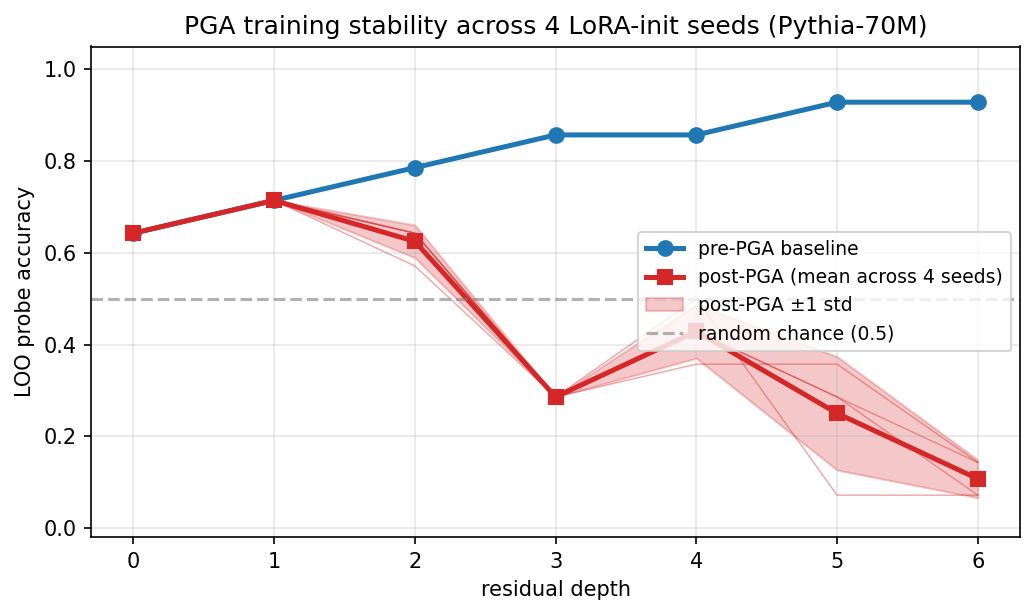

saved figure: MIDU/MLDU_E/artifacts/fig_mldu_e_pga_multiseed.png

  PAPER-READY SUMMARY
  L0:  post-PGA = 0.643 ± 0.000  (min 0.643, max 0.643)
  L1:  post-PGA = 0.714 ± 0.000  (min 0.714, max 0.714)
  L2:  post-PGA = 0.625 ± 0.036  (min 0.571, max 0.643)
  L3:  post-PGA = 0.286 ± 0.000  (min 0.286, max 0.286)
  L4:  post-PGA = 0.429 ± 0.058  (min 0.357, max 0.500)
  L5:  post-PGA = 0.250 ± 0.124  (min 0.071, max 0.357)
  L6:  post-PGA = 0.107 ± 0.041  (min 0.071, max 0.143)

  $4$ LoRA-init seeds, deepest layer L6 = 0.107 ± 0.041


In [8]:
import matplotlib.pyplot as plt

depths = list(range(N_HIDDEN))
post_matrix = np.array([
    [all_seed_results[s][str(d)] for d in depths]
    for s in SEEDS
])  # shape (n_seeds, n_depths)

post_mean = post_matrix.mean(axis=0)
post_std  = post_matrix.std(axis=0, ddof=1) if len(SEEDS) > 1 else np.zeros_like(post_mean)
post_min  = post_matrix.min(axis=0)
post_max  = post_matrix.max(axis=0)
pre_arr   = np.array([pre[d] for d in depths])

print(f'\n{"layer":<6}{"pre":>7}{"post mean":>11}{"post std":>11}{"post min":>11}{"post max":>11}')
print('-' * 56)
for d in depths:
    print(f'  L{d:<3} {pre_arr[d]:>7.3f}{post_mean[d]:>11.3f}{post_std[d]:>11.3f}{post_min[d]:>11.3f}{post_max[d]:>11.3f}')

# save aggregate JSON
agg_out = ART / 'mldu_e_pga_pythia70m_multiseed.json'
json.dump({
    'model': MODEL_NAME,
    'seeds': [int(s) for s in SEEDS],
    'lora_r': LORA_R, 'epochs': EPOCHS,
    'lambda_align': LAMBDA_ALIGN, 'lambda_ce': LAMBDA_CE,
    'pre_per_layer':       {str(d): float(pre_arr[d]) for d in depths},
    'post_per_layer_mean': {str(d): float(post_mean[d]) for d in depths},
    'post_per_layer_std':  {str(d): float(post_std[d])  for d in depths},
    'post_per_layer_min':  {str(d): float(post_min[d])  for d in depths},
    'post_per_layer_max':  {str(d): float(post_max[d])  for d in depths},
    'per_seed':            {str(s): all_seed_results[s] for s in SEEDS},
    'peak_gap_layer': PROBE_LAYER,
}, open(agg_out, 'w'), indent=2)
print(f'\nsaved aggregate: {agg_out}')

# --- figure: per-layer accuracy with std band ---
fig, ax = plt.subplots(figsize=(7, 4.2), dpi=150)
ax.plot(depths, pre_arr, 'o-', color='#1f77b4', lw=2.4, ms=7, label=f'pre-PGA baseline')
ax.plot(depths, post_mean, 's-', color='#d62728', lw=2.4, ms=7,
        label=f'post-PGA (mean across {len(SEEDS)} seeds)')
ax.fill_between(depths, post_mean - post_std, post_mean + post_std,
                alpha=0.25, color='#d62728', label=f'post-PGA \u00b11 std')
for s in SEEDS:
    seed_curve = [all_seed_results[s][str(d)] for d in depths]
    ax.plot(depths, seed_curve, '-', color='#d62728', lw=0.7, alpha=0.4)
ax.axhline(0.5, ls='--', color='gray', alpha=0.6, label='random chance (0.5)')
ax.set_xlabel('residual depth')
ax.set_ylabel('LOO probe accuracy')
ax.set_title(f'PGA training stability across {len(SEEDS)} LoRA-init seeds (Pythia-70M)')
ax.set_xticks(depths)
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='center right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = ART / 'fig_mldu_e_pga_multiseed.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved figure: {fig_path}')

print('\n' + '=' * 72)
print('  PAPER-READY SUMMARY')
print('=' * 72)
for d in depths:
    print(f'  L{d}:  post-PGA = {post_mean[d]:.3f} \u00b1 {post_std[d]:.3f}  '
          f'(min {post_min[d]:.3f}, max {post_max[d]:.3f})')
print(f'\n  ${len(SEEDS)}$ LoRA-init seeds, deepest layer L{depths[-1]} = '
      f'{post_mean[-1]:.3f} \u00b1 {post_std[-1]:.3f}')